In [1]:
import numpy as np
import os
import imageio
from skimage.transform import resize, rescale
import datetime
from glob import glob
import piq
import torch

import cv2
import matplotlib.pyplot as plt

In [2]:
if not hasattr(np, 'typeDict'):
    np.typeDict = np.sctypeDict

In [4]:
import tensorflow as tf
import math

def gaussian_kernel(size, sigma):
    """Creates a 2D Gaussian kernel."""
    ax = tf.range(-size // 2 + 1, size // 2 + 1, dtype=tf.float32)
    xx, yy = tf.meshgrid(ax, ax)
    kernel = tf.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / tf.reduce_sum(kernel)
    return kernel


def gaussian_blur(img, sigma):
    """
    img must be (B, H, W, 1)
    """

    tf.debugging.assert_rank(img, 4, message="gaussian_blur expects 4D input")

    kernel_size = int(6 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = gaussian_kernel(kernel_size, sigma)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]

    return tf.nn.depthwise_conv2d(
        img,
        kernel,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )


In [5]:
def estimate_illumination(luma, sigma=15):
    """
    luma: (B, H, W, 1) OR (H, W, 1)
    returns: (B, H, W, 1)
    """

    # ✅ Ensure batch dimension
    if luma.shape.rank == 3:
        luma = tf.expand_dims(luma, axis=0)  # (1, H, W, 1)

    # Downsample
    small = tf.image.resize(luma, (64, 64))

    # Blur
    illum_small = gaussian_blur(small, sigma)

    # Upsample back
    illum = tf.image.resize(
        illum_small,
        tf.shape(luma)[1:3]
    )

    return illum


In [6]:
def percentile(x, q):
    x = tf.reshape(x, [-1])
    k = tf.cast(tf.round(q / 100.0 * tf.cast(tf.size(x), tf.float32)), tf.int32)
    x = tf.sort(x)
    return x[k]


In [7]:
def retinex_enhancement(img, sigmas=(15,), gamma=0.8, eps=1e-4):

    img = tf.clip_by_value(img, eps, 1.0)

    luma = tf.reduce_max(img, axis=-1, keepdims=True)

    illum_maps = []
    for sigma in sigmas:
        illum = estimate_illumination(luma, sigma)
        illum_maps.append(illum)

    illumination = tf.reduce_mean(tf.stack(illum_maps), axis=0)
    illumination = tf.clip_by_value(illumination, eps, 1.0)

    reflectance = img / (illumination + eps)
    reflectance = tf.clip_by_value(reflectance, 0.0, 1.0)

    enhanced = reflectance * tf.pow(illumination, gamma)
    enhanced = tf.clip_by_value(enhanced, 0.0, 1.0)

    return enhanced, reflectance, illumination

In [8]:
def retinex_map(img):
    enhanced, _, illum = retinex_enhancement(img)
    return enhanced, illum


In [9]:
def flatten_sequence(x):
    return tf.data.Dataset.from_tensor_slices((x))


In [10]:
import tensorflow as tf
from tensorflow.keras import layers
def channel_attention(x, reduction=8):
    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    shared_dense_1 = layers.Dense(
        channels // reduction,
        activation="relu",
        kernel_initializer="he_normal"
    )

    shared_dense_2 = layers.Dense(
        channels,
        kernel_initializer="he_normal"
    )

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    scale = layers.Add()([avg_out, max_out])
    scale = layers.Activation("sigmoid")(scale)

    scale = layers.Reshape((1, 1, channels))(scale)

    # Slight residual scaling to prevent over-suppression
    scale = layers.Lambda(lambda t: 0.5 + 0.5 * t)(scale)

    return layers.Multiply()([x, scale])


def spatial_attention(x):
    avg_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    scale = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid",
        kernel_initializer="he_normal"
    )(concat)

    # residual scaling
    scale = layers.Lambda(lambda t: 0.5 + 0.5 * t)(scale)

    return layers.Multiply()([x, scale])


def IAM(x):
    # Try spatial first for LLIE
    x = spatial_attention(x)
    x = channel_attention(x)
    return x

In [11]:
def ASPP(x, filters=256):

    shape = x.shape

    y1 = layers.Conv2D(filters, 1, padding="same", activation="relu")(x)

    y2 = layers.Conv2D(filters, 3, dilation_rate=3,
                       padding="same", activation="relu")(x)

    y3 = layers.Conv2D(filters, 3, dilation_rate=6,
                       padding="same", activation="relu")(x)

    y4 = layers.Conv2D(filters, 3, dilation_rate=9,
                       padding="same", activation="relu")(x)

    y = layers.Concatenate()([y1, y2, y3, y4])

    y = layers.Conv2D(filters, 1, padding="same", activation="relu")(y)

    return y



In [12]:
from tensorflow.keras import Model, Input
def conv_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.05)(x)

    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.LeakyReLU(alpha=0.05)(x)

    return x

def downsample_block(x, filters):
    x = layers.Conv2D(filters, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def build_unet_iam(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = downsample_block(c1, 64)

    c2 = conv_block(p1, 64)
    p2 = downsample_block(c2, 128)

    c3 = conv_block(p2, 128)
    p3 = downsample_block(c3, 256)

    # Bottleneck
    bn = conv_block(p3, 256)
    bn = ASPP(bn)   # multi-scale context

    # Decoder with gated skip
    u3 = layers.UpSampling2D()(bn)
    gated_c3 = IAM(c3)
    u3 = layers.Concatenate()([u3, gated_c3])
    c4 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c4)
    gated_c2 = IAM(c2)
    u2 = layers.Concatenate()([u2, gated_c2])
    c5 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c5)
    gated_c1 = IAM(c1)
    u1 = layers.Concatenate()([u1, gated_c1])
    c6 = conv_block(u1, 32)

    outputs = layers.Conv2D(3, (1, 1), activation='tanh', kernel_initializer='zeros')(c6)

    return Model(inputs, outputs)


In [13]:
unet_iam = build_unet_iam()

C:\Python\anaconda3\envs\lowlight\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [14]:
import keras
import tensorflow as tf

print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# Check if Keras is running the correct backend
print(f"Keras backend: {keras.backend.backend()}")

Keras version: 3.10.0
TensorFlow version: 2.20.0
Keras backend: tensorflow


In [15]:
unet_iam.load_weights("final_colab_unet_iam.weights.h5")

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_discriminator(input_shape=(256, 256, 3)):
    """Standard patch-based discriminator (Global or Local)."""
    inputs = layers.Input(shape=input_shape)

    def d_block(x, filters, stride=2):
        x = layers.Conv2D(filters, 4, strides=stride, padding='same')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.BatchNormalization()(x)
        return x

    x = d_block(inputs, 64)
    x = d_block(x, 128)
    x = d_block(x, 256)
    x = d_block(x, 512, stride=1)

    outputs = layers.Conv2D(1, 4, padding='same')(x)
    return Model(inputs, outputs)

# Initialize global and local discriminators
global_disc = build_discriminator()
local_disc = build_discriminator(input_shape=(None, None, 3)) # For random patches

In [17]:
class EnlightenGAN(Model):
    def __init__(self, generator, global_disc, local_disc):
        super(EnlightenGAN, self).__init__()
        self.generator = generator
        self.global_disc = global_disc
        self.local_disc = local_disc
        self.vgg = self._build_vgg()
        self.mae = tf.keras.losses.MeanAbsoluteError()

    def _build_vgg(self):
        vgg = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
        vgg.trainable = False
        return Model(vgg.input, vgg.get_layer('block3_conv3').output)

    def compile(self, g_opt, d_opt):
        super(EnlightenGAN, self).compile()
        self.g_opt = g_opt
        self.d_opt = d_opt

    def get_random_patch(self, img, patch_size=64):
        return tf.image.random_crop(img, size=[tf.shape(img)[0], patch_size, patch_size, 3])

    # Updated Frequency Loss to prevent gradient loss
    def frequency_loss(self, pred, target):
        pred_gray = tf.image.rgb_to_grayscale(pred)
        target_gray = tf.image.rgb_to_grayscale(target)
        
        # Cast to complex for FFT
        pred_fft = tf.signal.fft2d(tf.cast(pred_gray, tf.complex64))
        target_fft = tf.signal.fft2d(tf.cast(target_gray, tf.complex64))
        
        # Compare the MAGNITUDE (absolute value) of the frequencies
        # This avoids discarding the imaginary part incorrectly
        return tf.reduce_mean(tf.abs(tf.abs(pred_fft) - tf.abs(target_fft)))


    @tf.function
    def train_step(self, low_light):
        gamma = 0.4 
        real_target = tf.pow(low_light, gamma)

        # --- 1. Train Discriminator (Once) ---
        with tf.GradientTape() as d_tape:
            res = self.generator(low_light, training=True)
            enhanced = tf.clip_by_value(low_light + res, 0.0, 1.0)
            
            # Instance noise helps prevent the Discriminator from becoming too perfect
            noise = tf.random.normal(tf.shape(enhanced), stddev=0.05)
            
            # Global Discriminator
            fake_g_logit = self.global_disc(enhanced + noise, training=True)
            real_g_logit = self.global_disc(real_target + noise, training=True)
            
            # Local Discriminator (Fixes the "Gradients do not exist" warning)
            # We take a random crop to train the local patches
            fake_patch = tf.image.random_crop(enhanced + noise, [tf.shape(enhanced)[0], 32, 32, 3])
            real_patch = tf.image.random_crop(real_target + noise, [tf.shape(real_target)[0], 32, 32, 3])
            fake_l_logit = self.local_disc(fake_patch, training=True)
            real_l_logit = self.local_disc(real_patch, training=True)
            
            # Combined LSGAN Loss
            d_loss_g = 0.5 * (tf.reduce_mean(tf.square(real_g_logit - 0.9)) + tf.reduce_mean(tf.square(fake_g_logit)))
            d_loss_l = 0.5 * (tf.reduce_mean(tf.square(real_l_logit - 0.9)) + tf.reduce_mean(tf.square(fake_l_logit)))
            d_loss = d_loss_g + d_loss_l

        d_grads = d_tape.gradient(d_loss, self.global_disc.trainable_variables + self.local_disc.trainable_variables)
        self.d_opt.apply_gradients(zip(d_grads, self.global_disc.trainable_variables + self.local_disc.trainable_variables))

        # --- 2. Train Generator (Twice to catch up) ---
        for _ in range(2):
            with tf.GradientTape() as g_tape:
                res = self.generator(low_light, training=True)
                enhanced = tf.clip_by_value(low_light + res, 0.0, 1.0)
                
                fake_g_logit = self.global_disc(enhanced, training=True)
                fake_l_logit = self.local_disc(tf.image.random_crop(enhanced, [tf.shape(enhanced)[0], 32, 32, 3]), training=True)
                
                # Adversarial Loss (Global + Local)
                g_adv = tf.reduce_mean(tf.square(fake_g_logit - 1.0)) + tf.reduce_mean(tf.square(fake_l_logit - 1.0))
                
                # Content and Exposure
                content_loss = self.mae(self.vgg(real_target), self.vgg(enhanced))
                over_exposure_penalty = tf.reduce_mean(tf.maximum(enhanced - 0.9, 0.0))
                
                # Boost adversarial weight if Generator is stagnant
                total_g_loss = (5.0 * g_adv) + (1.0 * content_loss) + (10.0 * over_exposure_penalty)

            g_grads = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
            self.g_opt.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        return {"g_loss": total_g_loss, "d_loss": d_loss}

In [18]:
enlighten_gan = EnlightenGAN(
    generator=unet_iam,
    global_disc=global_disc,
    local_disc=local_disc
)


enlighten_gan.compile(
    g_opt=tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
    d_opt=tf.keras.optimizers.Adam(1e-5, beta_1=0.5)
)

In [19]:
import tensorflow as tf

# 1. Build the sub-components
# Use your unet_iam, global_disc, and local_disc definitions
unet_iam = build_unet_iam() # Ensure this matches the 53-layer architecture
global_disc = build_discriminator()
local_disc = build_discriminator(input_shape=(None, None, 3))

# 2. Instantiate the wrapper
enlighten_gan = EnlightenGAN(
    generator=unet_iam,
    global_disc=global_disc,
    local_disc=local_disc
)

# 3. Load the weights (Using the files you have in hand)
# You only need the generator for PSNR, but loading all for completeness:
enlighten_gan.generator.load_weights("final_generator.weights.h5")
enlighten_gan.global_disc.load_weights("final_global_discriminator.weights.h5")
enlighten_gan.local_disc.load_weights("final_local_discriminator.weights.h5")

print("Model successfully reconstructed and weights loaded.")

Model successfully reconstructed and weights loaded.


In [20]:
import glob
DATA_DIR = "preprocessed"

all_clean_image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    all_clean_image_paths.extend(
        glob.glob(os.path.join(DATA_DIR, "**", ext), recursive=True)
    )

len(all_clean_image_paths)


37763

In [21]:
import tensorflow as tf

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (256, 256))
    img = tf.cast(img, tf.float32) / 255.0
    return img

ds = tf.data.Dataset.from_tensor_slices(all_clean_image_paths)
ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(3)


In [22]:
train_ds = (
    ds
    .flat_map(flatten_sequence)
    .batch(4)
    .prefetch(tf.data.AUTOTUNE)
)
monitor_sample = next(iter(train_ds.take(1)))
monitor_sample = monitor_sample[:1]

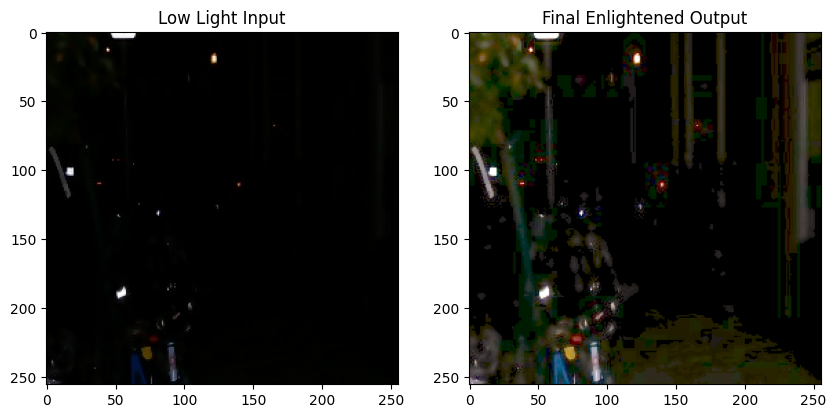

In [23]:
def compare_stages(low_light_sample):


    # enhanced, _, _ = retinex_enhancement(low_light_sample)
    residual = enlighten_gan.generator(low_light_sample, training=True)
    gamma = tf.clip_by_value(1.2 - 0.5 * residual, 0.8, 1.4)



    # enhanced = tf.clip_by_value(low_light_sample + residual, 0.0, 1.0)
    # enhanced = tf.clip_by_value(low_light_sample + (residual * 0.5 + 0.5), 0.0, 1.0)
    enhanced = tf.clip_by_value(low_light_sample + residual, 0.0, 1.0)
    # enhanced = tf.pow(enhanced + 1e-6, gamma)


    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Low Light Input")
    plt.imshow(low_light_sample[0])

    plt.subplot(1,2,2)
    plt.title("Final Enlightened Output")
    plt.imshow(enhanced[0])
    plt.show()

compare_stages(monitor_sample)

In [26]:
# =========================================================
# Imports
# =========================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import skvideo.measure
import imquality.brisque as brisque
import skimage.transform

# =========================================================
# Compatibility Fixes
# =========================================================

# NumPy compatibility (for old libraries)
np.int = int
np.float = float
np.bool = bool

# Patch for BRISQUE multichannel issue
# orig_rescale = skimage.transform.rescale

# def patched_rescale(*args, **kwargs):
#     kwargs.pop("multichannel", None)
#     return orig_rescale(*args, **kwargs)

# skimage.transform.rescale = patched_rescale


# =========================================================
# Dataset Paths
# =========================================================

low_test_path = "Dataset/LoLI-Street Dataset/Train_new/low"
high_test_path = "Dataset/LoLI-Street Dataset/Train_new/high"


# =========================================================
# Score Containers
# =========================================================

gan_psnr_scores = []
low_psnr_scores = []

gan_ssim_scores = []
low_ssim_scores = []

# gan_niqe_scores = []
# low_niqe_scores = []

# gan_brisque_scores = []
# low_brisque_scores = []


# =========================================================
# Image List
# =========================================================

image_list = sorted(os.listdir(low_test_path))

# Optional speed test
# image_list = image_list[:200]


# =========================================================
# Evaluation Loop
# =========================================================

for img_name in image_list:

    low_path = os.path.join(low_test_path, img_name)
    high_path = os.path.join(high_test_path, img_name)

    if not os.path.exists(high_path):
        continue

    # -----------------------------------------------------
    # Read Images
    # -----------------------------------------------------

    low_img = cv2.imread(low_path)
    high_img = cv2.imread(high_path)

    if low_img is None or high_img is None:
        continue

    low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
    high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

    # -----------------------------------------------------
    # Resize
    # -----------------------------------------------------

    low_img = cv2.resize(low_img, (256, 256))
    high_img = cv2.resize(high_img, (256, 256))

    # -----------------------------------------------------
    # Normalize
    # -----------------------------------------------------

    low_img = low_img.astype(np.float32) / 255.0
    high_img = high_img.astype(np.float32) / 255.0

    # -----------------------------------------------------
    # Batch dimension
    # -----------------------------------------------------

    low_batch = np.expand_dims(low_img, axis=0)
    high_batch = np.expand_dims(high_img, axis=0)

    # -----------------------------------------------------
    # GAN Enhancement
    # -----------------------------------------------------

    residual = enlighten_gan.generator(low_batch, training=False)

    enhanced = tf.clip_by_value(low_batch + residual, 0.0, 1.0)

    enhanced_np = enhanced.numpy()[0]

    # -----------------------------------------------------
    # PSNR
    # -----------------------------------------------------

    gan_psnr = tf.image.psnr(enhanced, high_batch, max_val=1.0)
    low_psnr = tf.image.psnr(low_batch, high_batch, max_val=1.0)

    gan_psnr_scores.append(float(gan_psnr.numpy()[0]))
    low_psnr_scores.append(float(low_psnr.numpy()[0]))

    # -----------------------------------------------------
    # SSIM
    # -----------------------------------------------------

    gan_ssim = tf.image.ssim(enhanced, high_batch, max_val=1.0)
    low_ssim = tf.image.ssim(low_batch, high_batch, max_val=1.0)

    gan_ssim_scores.append(float(gan_ssim.numpy()[0]))
    low_ssim_scores.append(float(low_ssim.numpy()[0]))

    # -----------------------------------------------------
    # Convert to uint8
    # -----------------------------------------------------

    enhanced_uint8 = np.clip(enhanced_np * 255, 0, 255).astype(np.uint8)
    low_uint8 = np.clip(low_img * 255, 0, 255).astype(np.uint8)

    # -----------------------------------------------------
    # NIQE (grayscale)
    # -----------------------------------------------------

#     enhanced_gray = cv2.cvtColor(enhanced_uint8, cv2.COLOR_RGB2GRAY)
#     low_gray = cv2.cvtColor(low_uint8, cv2.COLOR_RGB2GRAY)

#     gan_niqe = skvideo.measure.niqe(enhanced_gray)
#     low_niqe = skvideo.measure.niqe(low_gray)

#     gan_niqe_scores.append(float(gan_niqe[0]))
#     low_niqe_scores.append(float(low_niqe[0]))


    # -----------------------------------------------------
    # BRISQUE (force RGB + PIL format)
    # -----------------------------------------------------

#     from PIL import Image

#     enhanced_rgb = cv2.cvtColor(enhanced_uint8, cv2.COLOR_BGR2RGB)
#     low_rgb = cv2.cvtColor(low_uint8, cv2.COLOR_BGR2RGB)

#     enhanced_pil = Image.fromarray(enhanced_rgb)
#     low_pil = Image.fromarray(low_rgb)

#     gan_brisque = brisque.score(enhanced_pil)
#     low_brisque = brisque.score(low_pil)

#     gan_brisque_scores.append(float(gan_brisque))
#     low_brisque_scores.append(float(low_brisque))


# =========================================================
# Final Results
# =========================================================

print("\n===================================")
print("        FINAL EVALUATION")
print("===================================")

print("\nPSNR")
print("GAN :", np.mean(gan_psnr_scores))
print("LOW :", np.mean(low_psnr_scores))

print("\nSSIM")
print("GAN :", np.mean(gan_ssim_scores))
print("LOW :", np.mean(low_ssim_scores))

# print("\nNIQE (Lower is Better)")
# print("GAN :", np.mean(gan_niqe_scores))
# print("LOW :", np.mean(low_niqe_scores))

# print("\nBRISQUE (Lower is Better)")
# print("GAN :", np.mean(gan_brisque_scores))
# print("LOW :", np.mean(low_brisque_scores))


        FINAL EVALUATION

PSNR
GAN : 16.537174680074056
LOW : 9.604758290926615

SSIM
GAN : 0.8284307782649993
LOW : 0.582567672808965


In [28]:
import os
import cv2
import numpy as np
import tensorflow as tf

output_dir = "new_enhanced_results"
os.makedirs(output_dir, exist_ok=True)

print("Generating GAN enhanced images...")

for i, low_batch in enumerate(train_ds.take(100)):

    # Get GAN residual
    residual = enlighten_gan.generator(low_batch, training=False)

    # Clip values to [0,1]
    enhanced = tf.clip_by_value(low_batch + residual, 0.0, 1.0)

    # Convert to uint8 for OpenCV
    enhanced_uint8 = (enhanced[0].numpy() * 255).astype(np.uint8)  # Take first image if batch

    # Apply denoising
    enhanced_uint8 = cv2.fastNlMeansDenoisingColored(enhanced_uint8, None, 10, 10, 7, 21)

    # Apply gamma correction
    gamma = 0.9
    enhanced_uint8 = np.power(enhanced_uint8 / 255.0, gamma) * 255
    enhanced_uint8 = enhanced_uint8.astype(np.uint8)

    # Apply bilateral filter
    enhanced_uint8 = cv2.bilateralFilter(enhanced_uint8, 9, 75, 75)

    # Final image (already uint8)
    pred_img = enhanced_uint8

    # Save
    save_path = os.path.join(output_dir, f"gan_img_{i}.png")
    cv2.imwrite(save_path, pred_img)

print("GAN enhanced images saved.")

Generating GAN enhanced images...
GAN enhanced images saved.
